In [34]:
import numpy as np
import json
import re
import os
import string
from IPython.display import display, HTML

import tensorflow as tf
from tensorflow.keras import layers, models, losses, callbacks

# 0. Parameters

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 80
EMBEDDING_DIM = 256
KEY_DIM = 256
N_HEADS = 2
FEED_FORWARD_DIM = 256
VALIDATION_SPLIT = 0.2
SEED = 42
LOAD_MODEL = False
BATCH_SIZE = 32
EPOCHS = 5

# 1. Load the data

In [4]:
# 1. Go to Kaggle → Account Settings
# - Click "Create New API Token" → this downloads kaggle.json.

# 2. Upload it in Colab:

from google.colab import files
uploaded = files.upload()  # Upload the kaggle.json file here

Saving kaggle.json to kaggle.json


In [5]:
# Setup the API credentials:

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d aminbamavadat/winemagdata130kv2
!unzip -q winemagdata130kv2.zip

import json

with open("winemag-data-130k-v2.json") as json_data:
    wine_data = json.load(json_data)

Dataset URL: https://www.kaggle.com/datasets/aminbamavadat/winemagdata130kv2
License(s): unknown
  0% 0.00/17.8M [00:00<?, ?B/s]
100% 17.8M/17.8M [00:00<00:00, 1.27GB/s]


In [7]:
wine_data[10]

{'points': '87',
 'title': 'Kirkland Signature 2011 Mountain Cuvée Cabernet Sauvignon (Napa Valley)',
 'description': 'Soft, supple plum envelopes an oaky structure in this Cabernet, supported by 15% Merlot. Coffee and chocolate complete the picture, finishing strong at the end, resulting in a value-priced wine of attractive flavor and immediate accessibility.',
 'taster_name': 'Virginie Boone',
 'taster_twitter_handle': '@vboone',
 'price': 19,
 'designation': 'Mountain Cuvée',
 'variety': 'Cabernet Sauvignon',
 'region_1': 'Napa Valley',
 'region_2': 'Napa',
 'province': 'California',
 'country': 'US',
 'winery': 'Kirkland Signature'}

In [8]:
# Filter the dataset
filtered_data = [
    "wine review : "
    + x["country"]
    + " : "
    + x["province"]
    + " : "
    + x["variety"]
    + " : "
    + x["description"]
    for x in wine_data
    if x["country"] is not None
    and x["province"] is not None
    and x["variety"] is not None
    and x["description"] is not None
]

In [9]:
# Count the recipes
n_wines = len(filtered_data)
print(f"{n_wines} recipes loaded")

129907 recipes loaded


In [10]:
example = filtered_data[25]
print(example)

wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard-designated Pinot that hails from a high-elevation site. Small in production, it offers intense, full-bodied raspberry and blackberry steeped in smoky spice and smooth texture.


## 2. Tokenize the data

In [11]:
# Pad the punctuation, to treat them as separate 'words'
def pad_punctuation(s):
    s = re.sub(f"([{string.punctuation}, '\n'])", r" \1 ", s)
    s = re.sub(" +", " ", s)
    return s


text_data = [pad_punctuation(x) for x in filtered_data]

In [12]:
# Display an example of a recipe
example_data = text_data[25]
example_data

'wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard - designated Pinot that hails from a high - elevation site . Small in production , it offers intense , full - bodied raspberry and blackberry steeped in smoky spice and smooth texture . '

In [13]:
# Convert to a Tensorflow Dataset
text_ds = (
    tf.data.Dataset.from_tensor_slices(text_data)
    .batch(BATCH_SIZE)
    .shuffle(1000)
)

In [14]:
# Create a vectorisation layer
vectorize_layer = layers.TextVectorization(
    standardize="lower",
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN + 1,
)

In [15]:
# Adapt the layer to the training set
vectorize_layer.adapt(text_ds)
vocab = vectorize_layer.get_vocabulary()

In [16]:
# Display some token:word mappings
for i, word in enumerate(vocab[:10]):
    print(f"{i}: {word}")

0: 
1: [UNK]
2: :
3: ,
4: .
5: and
6: the
7: wine
8: a
9: of


In [17]:
# Display the same example converted to ints
example_tokenised = vectorize_layer(example_data)
print(example_tokenised.numpy())

[   7   10    2   20    2   29    2   43   62    2   55    5  243 4145
  453  634   26    9  497  499  667   17   12  142   14 2214   43   25
 2484   32    8  223   14 2213  948    4  594   17  987    3   15   75
  237    3   64   14   82   97    5   74 2633   17  198   49    5  125
   77    4    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0]


## 3. Create the Training Set

In [18]:
# Create the training set of recipes and the same text shifted by one word
def prepare_inputs(text):
    text = tf.expand_dims(text, -1)
    tokenized_sentences = vectorize_layer(text)
    x = tokenized_sentences[:, :-1]
    y = tokenized_sentences[:, 1:]
    return x, y


train_ds = text_ds.map(prepare_inputs)

In [19]:
example_input_output = train_ds.take(1).get_single_element()

In [20]:
# Example Input
example_input_output[0][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([   7,   10,    2,   40,    2,  239,    2,  279,    2,    6,  660,
         14, 1540,    1,  142, 1329,   47,    1,    1, 2653, 4567, 3352,
          9,    6, 3318,    9, 1288,    4,   12,   13,    8, 1140,   72,
         14,  993,    7,   11,  263,   26,    9, 2924,   49,    3,  806,
          5,  250,  973,  221,  383,    5,  499,  667,    4,   15,   18,
         21,    8,  799,    5, 1183, 2483,   11,  102,   34,    5,    8,
        134,    3,  629,   31,    4,    0,    0,    0,    0,    0,    0,
          0,    0,    0])>

In [21]:
# Example Output (shifted by one token)
example_input_output[1][0]

<tf.Tensor: shape=(80,), dtype=int64, numpy=
array([  10,    2,   40,    2,  239,    2,  279,    2,    6,  660,   14,
       1540,    1,  142, 1329,   47,    1,    1, 2653, 4567, 3352,    9,
          6, 3318,    9, 1288,    4,   12,   13,    8, 1140,   72,   14,
        993,    7,   11,  263,   26,    9, 2924,   49,    3,  806,    5,
        250,  973,  221,  383,    5,  499,  667,    4,   15,   18,   21,
          8,  799,    5, 1183, 2483,   11,  102,   34,    5,    8,  134,
          3,  629,   31,    4,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])>

## 4. Create the causal attention mask function

In [22]:
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0
    )
    return tf.tile(mask, mult)


np.transpose(causal_attention_mask(1, 10, 10, dtype=tf.int32)[0])

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=int32)

## 5. Create a Transformer Block layer

In [23]:
class TransformerBlock(layers.Layer):
    def __init__(self, num_heads, key_dim, embed_dim, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

## 6. Create the Token and Position Embedding

In [24]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "max_len": self.max_len,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config

## 7. Build the Transformer model

In [25]:
inputs = layers.Input(shape=(None,), dtype=tf.int32)
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)(inputs)
x, attention_scores = TransformerBlock(
    N_HEADS, KEY_DIM, EMBEDDING_DIM, FEED_FORWARD_DIM
)(x)
outputs = layers.Dense(VOCAB_SIZE, activation="softmax")(x)
gpt = models.Model(inputs=inputs, outputs=[outputs, attention_scores])
gpt.compile("adam", loss=[losses.SparseCategoricalCrossentropy(), None])

In [26]:
gpt.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, None, 256)      │     2,580,480 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ [(None, None, 256),    │       658,688 │
│ (TransformerBlock)              │ (None, 2, None, None)] │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 10000)    │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,809,168 (22.16 MB)

 Trainable params: 5,809,168 (22.16 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
if LOAD_MODEL:
    # model.load_weights('./models/model')
    gpt = models.load_model("./models/gpt", compile=True)

## 8. Train the Transformer

In [28]:
# Create a TextGenerator checkpoint
class TextGenerator(callbacks.Callback):
    def __init__(self, index_to_word, top_k=10):
        self.index_to_word = index_to_word
        self.word_to_index = {
            word: index for index, word in enumerate(index_to_word)
        }

    def sample_from(self, probs, temperature):
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs), probs

    def generate(self, start_prompt, max_tokens, temperature):
        start_tokens = [
            self.word_to_index.get(x, 1) for x in start_prompt.split()
        ]
        sample_token = None
        info = []
        while len(start_tokens) < max_tokens and sample_token != 0:
            x = np.array([start_tokens])
            y, att = self.model.predict(x, verbose=0)
            sample_token, probs = self.sample_from(y[0][-1], temperature)
            info.append(
                {
                    "prompt": start_prompt,
                    "word_probs": probs,
                    "atts": att[0, :, -1, :],
                }
            )
            start_tokens.append(sample_token)
            start_prompt = start_prompt + " " + self.index_to_word[sample_token]
        print(f"\ngenerated text:\n{start_prompt}\n")
        return info

    def on_epoch_end(self, epoch, logs=None):
        self.generate("wine review", max_tokens=80, temperature=1.0)

In [30]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/checkpoint.weights.h5",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

# Tokenize starting prompt
text_generator = TextGenerator(vocab)

In [31]:
history = gpt.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[model_checkpoint_callback, tensorboard_callback, text_generator],
)

Epoch 1/5
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5885
generated text:
wine review : argentina : mendoza province : malbec : gritty , briary , tangy black and fat in the palate with acidity aren ' t showing some sharp - tasting varietal flavors . this is [UNK] , 000 cases offers passion fruit with a compact front of soft , salty berry and clove notes . on the finish , but the finish from this tiny study can stand out . 

4060/4060 ━━━━━━━━━━━━━━━━━━━━ 191s 45ms/step - loss: 2.5884
Epoch 2/5
4059/4060 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.9755
generated text:
wine review : italy : veneto : nebbiolo : here ' s a simple rendering of pinot noir that opens with an enticing whiff of roasted hazelnut . the delicious palate offers candied fruit , star anise and clove . 

4060/4060 ━━━━━━━━━━━━━━━━━━━━ 111s 27ms/step - loss: 1.9755
Epoch 3/5
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.9001
generated text:
wine review : austria : niederösterreich : grüner veltliner 

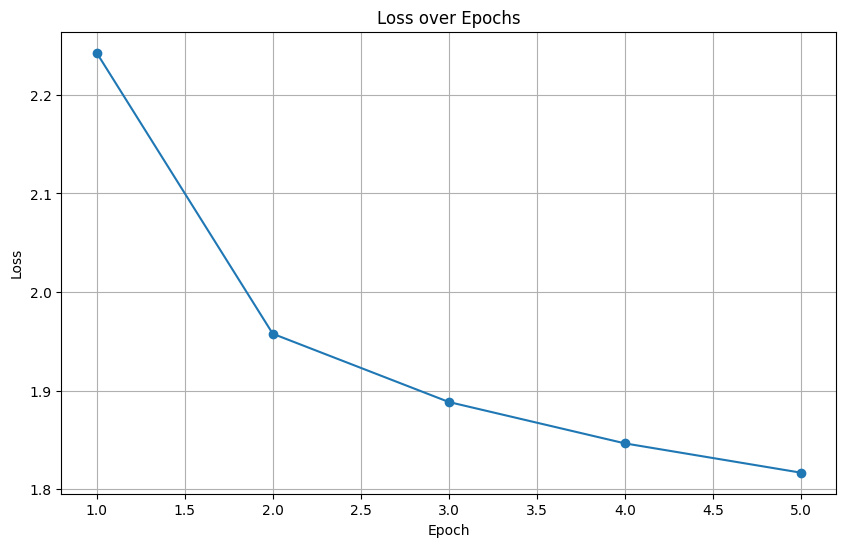

In [32]:
import matplotlib.pyplot as plt

# Extract the loss values
loss = history.history['loss']

# Plot the loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss)+1), loss, marker='o')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [35]:
# Create the 'models' directory if it doesn't exist
os.makedirs("./models", exist_ok=True)

# Save the final model
gpt.save("./models/gpt.keras")

## 9. Generate text using the Transformer

In [36]:
def print_probs(info, vocab, top_k=5):
    for i in info:
        highlighted_text = []
        for word, att_score in zip(
            i["prompt"].split(), np.mean(i["atts"], axis=0)
        ):
            highlighted_text.append(
                '<span style="background-color:rgba(135,206,250,'
                + str(att_score / max(np.mean(i["atts"], axis=0)))
                + ');">'
                + word
                + "</span>"
            )
        highlighted_text = " ".join(highlighted_text)
        display(HTML(highlighted_text))

        word_probs = i["word_probs"]
        p_sorted = np.sort(word_probs)[::-1][:top_k]
        i_sorted = np.argsort(word_probs)[::-1][:top_k]
        for p, i in zip(p_sorted, i_sorted):
            print(f"{vocab[i]}:   \t{np.round(100*p,2)}%")
        print("--------\n")

In [37]:
info = text_generator.generate(
    "wine review : us", max_tokens=80, temperature=1.0
)


generated text:
wine review : us : new york : riesling : waxy lemon - grapefruit and grapefruit flavors seem like this wine , accented by pleasant honeycomb and red apple with some stem to lend a citrusy kick on the palate . dusty mineral - sweet tannins make for a rich finish . 



In [38]:
info = text_generator.generate(
    "wine review : italy", max_tokens=80, temperature=0.5
)


generated text:
wine review : italy : tuscany : red blend : aromas of red berry , leather , spice and leather lead the nose . the palate offers dried black cherry , licorice and tobacco alongside tightly wound tannins . drink 2016–2021 . 



In [39]:
info = text_generator.generate(
    "wine review : germany", max_tokens=80, temperature=0.5
)
print_probs(info, vocab)


generated text:
wine review : germany : mosel : riesling : whiffs of smoke and slate lend a savory tone to this fruity , off - dry riesling . it ' s zesty in texture , with a dancing , delicate mouthfeel . light in style , it ' s delicate in concentration , but the finish is exhilarating . 



::   	100.0%
-:   	0.0%
grosso:   	0.0%
blanc:   	0.0%
blend:   	0.0%
--------



mosel:   	96.69999694824219%
rheingau:   	1.6200000047683716%
rheinhessen:   	1.5399999618530273%
pfalz:   	0.10000000149011612%
nahe:   	0.019999999552965164%
--------



::   	95.88999938964844%
-:   	4.110000133514404%
grosso:   	0.0%
blend:   	0.0%
blanca:   	0.0%
--------



riesling:   	100.0%
pinot:   	0.0%
grüner:   	0.0%
gewürztraminer:   	0.0%
spätburgunder:   	0.0%
--------



...

finish:   	89.13999938964844%
wine:   	6.53000020980835%
palate:   	1.7100000381469727%
flavors:   	1.149999976158142%
mouthfeel:   	0.5099999904632568%
--------



is:   	60.90999984741211%
lingers:   	32.720001220703125%
offers:   	3.5199999809265137%
shows:   	0.8399999737739563%
.:   	0.7300000190734863%
--------



marked:   	63.58000183105469%
brisk:   	5.519999980926514%
refreshing:   	3.5199999809265137%
exhilarating:   	3.240000009536743%
thirst:   	3.069999933242798%
--------



.:   	98.86000061035156%
and:   	0.9100000262260437%
,:   	0.1599999964237213%
with:   	0.05000000074505806%
in:   	0.009999999776482582%
--------



:   	97.08000183105469%
drink:   	2.9100000858306885%
enjoy:   	0.0%
it:   	0.0%
drinks:   	0.0%
--------

